# 🎨 Sổ Tay Học Trực Quan Hóa Dữ Liệu (Bản Masterclass Tối Thượng)

Phiên bản này có mặt **13 LOẠI BIỂU ĐỒ** quan trọng nhất giới Khoa học Dữ liệu.
Không chỉ hướng dẫn vẽ, cuốn sổ tay này mổ xẻ cả: 
1. **Mục đích (Khi nào dùng?)**
2. **Điều Kiện Lý Tưởng (Điểm Ngọt Ngào)**
3. **⚠️ NHƯỢC ĐIỂM CHẾT NGƯỜI (Cạm Bẫy Phải Tránh)**

Dữ liệu thực hành: **Normalized của Trạm 1 (`norm_station_1.csv`)**.

---
## 📦 Bước 0: Chuẩn bị Thư viện và Dữ liệu

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Cấu hình thẩm mỹ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

file_path = '../data/normalized/norm_station_1.csv'
df = pd.read_csv(file_path, parse_dates=['timestamp'])
df = df.set_index('timestamp')
display(df[['pm25', 'temp', 'rh', 'wind_spd', 'is_weekend_holiday']].head())

,pm25,temp,rh,wind_spd,is_weekend_holiday
timestamp,,,,,
2023-01-01 00:00:00,0.492060,-2.474490,0.743590,0.137931,1
2023-01-01 01:00:00,0.700316,-2.565723,0.782051,0.132184,1
2023-01-01 02:00:00,0.791744,-2.620462,0.807692,0.132184,1
2023-01-01 03:00:00,0.992654,-2.620462,0.794872,-0.034483,1
2023-01-01 04:00:00,0.583488,-2.693448,0.820513,0.143678,1


---
## 📈 1. Line Plot (Biểu Đồ Đường)

**🎯 Mục đích:** Theo dõi sự thay đổi (Xu hướng/Trend) theo một trật tự cụ thể liên tiếp.

**✨ Điều Kiện Lý Tưởng:** Dữ liệu Chuỗi thời gian liên tục (Time Series). Trục X sắp xếp tăng dần logic.

**⚠️ NHƯỢC ĐIỂM CỐ HỮU (Weakness):** Cực kỳ rối (Hiện tượng Spaghetti) nếu nhồi nhét quá $5-6$ đường lấn lên nhau trên cùng 1 biểu đồ. Không quan sát được số lượng tập trung (Mật độ) trong khối dữ liệu.

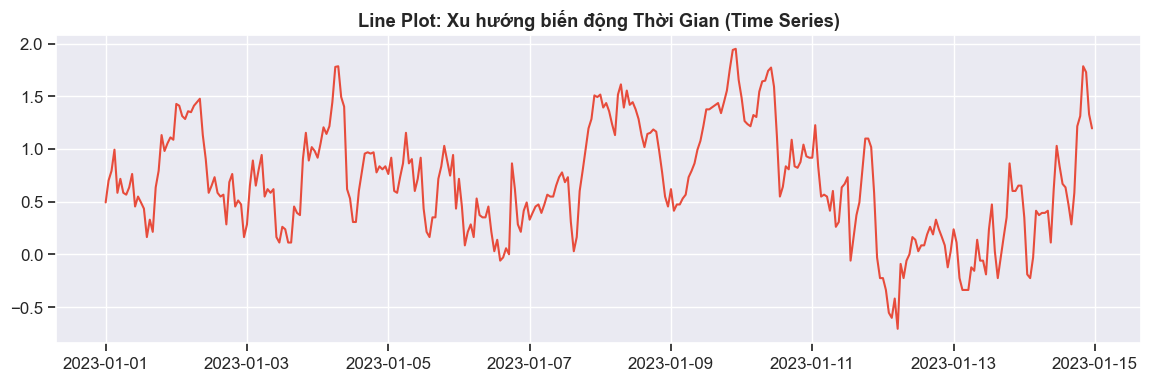

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
subset = df.iloc[:336] # 2 tuần lễ
ax.plot(subset.index, subset['pm25'], color='#e74c3c', linewidth=1.5)
ax.set_title('Line Plot: Xu hướng biến động Thời Gian (Time Series)', fontweight='bold')
plt.show()

---
## 🌌 2. Scatter Plot (Biểu Đồ Phân Tán)

**🎯 Mục đích:** Tìm Mối Tương Quan (Rủi ro đi kèm) giữa 2 nhân tố định lượng.

**✨ Điều Kiện Lý Tưởng:** Trục X và Y là đồ họa Continuous, $< 5000$ điểm chấm.

**⚠️ NHƯỢC ĐIỂM (Weakness):** Nạn **Overplotting**. Nếu ném 3 vạn dữ liệu vào, khu vực trung tâm sẽ trở thành một Vệt Mực Đen Xì, đè bẹp hết các đốm, bạn không thể đo lường xem điểm giữa nó tập trung đặc nhuyễn hay mỏng.

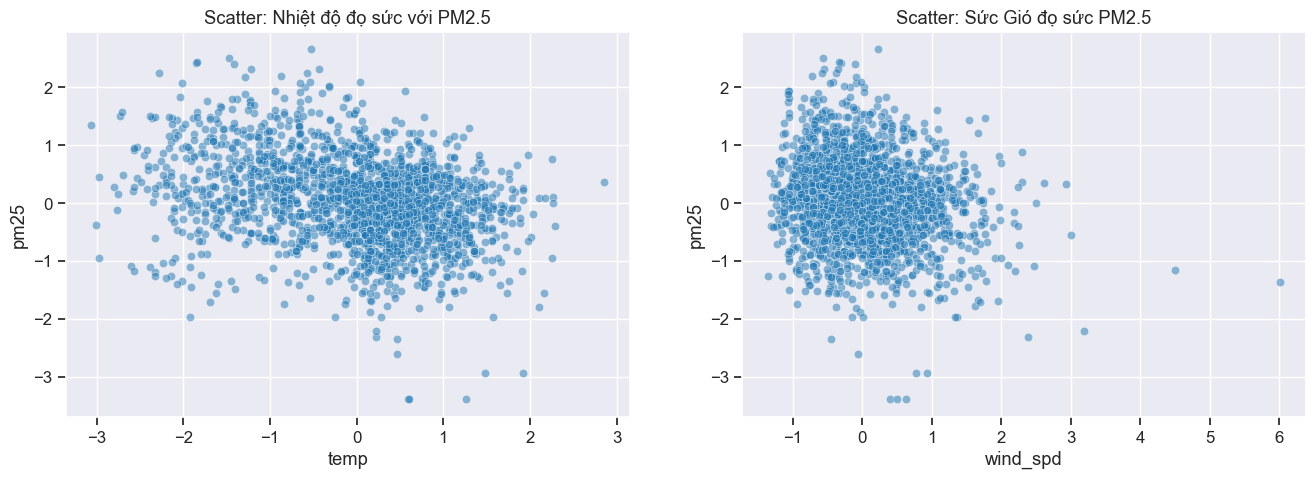

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df_sample = df.sample(2000, random_state=42) # Khắc phục nhược điểm bằng cách Sample giảm số lượng

sns.scatterplot(data=df_sample, x='temp', y='pm25', alpha=0.5, ax=axes[0])
axes[0].set_title('Scatter: Nhiệt độ đọ sức với PM2.5')

sns.scatterplot(data=df_sample, x='wind_spd', y='pm25', alpha=0.5, ax=axes[1])
axes[1].set_title('Scatter: Sức Gió đọ sức PM2.5')
plt.show()

---
## 📊 3. Histogram & KDE (Cắt Lớp Hình Khoang)

**🎯 Mục đích:** Chiếu thẳng X-Ray xem một loại Dữ Liệu mập mạp bóp méo dồn dập ở ngưỡng nào nhất?

**✨ Điều Kiện Lý Tưởng:** Phân bổ 1 yếu tố chạy dọc trục $x$ dài ngoằng.

**⚠️ NHƯỢC ĐIỂM (Weakness):** Hình học của nó sẽ KHÁC HOÀN TOÀN nếu bạn vô tình set số `bins` (Số ô chia) sai. Đường vẽ ảo giác KDE (Đường dây vẽ trùm kín núi) thường có thói quen NỘI SUY vô lý (Ví dụ tự tin đánh dấu đường xuống dưới 0 độ K dù dữ liệu thực tế ko có số âm).

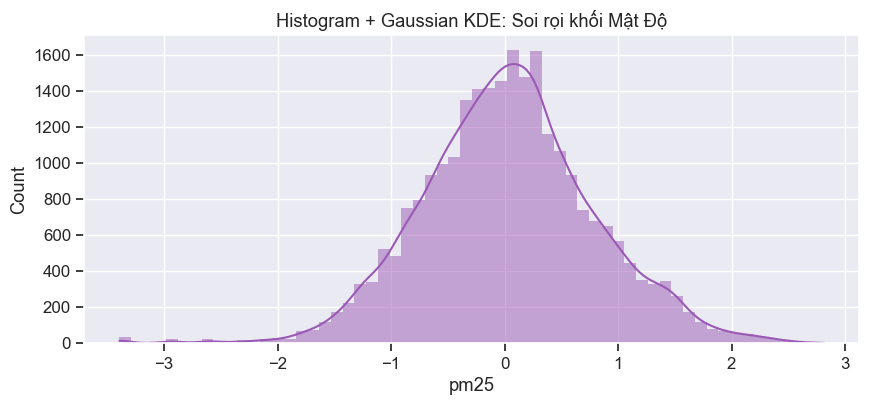

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df['pm25'], bins=60, kde=True, color='#9b59b6', edgecolor='none', ax=ax)
ax.set_title('Histogram + Gaussian KDE: Soi rọi khối Mật Độ')
plt.show()

---
## 📦 4. Box Plot (Hộp Đóng Thùng Outliers)

**🎯 Mục đích:** Liếc mắt phân định tức tốc Ranh Giới Giữa của các Quần Cư dữ liệu (Categorical).

**✨ Điều Kiện Lý Tưởng:** Xếp thành Nhóm Hạng (Categorical Trục X), Trục Y nhô thẳng.

**⚠️ NHƯỢC ĐIỂM (Weakness):** Nó "Che Giấu" đi kết cấu sự thật trong lòng hộp xốp. Nếu dữ liệu có hình ngọn núi lửa đôi (Bimodal - Lõm chính giữa rỗng), thì cái hộp Vuông này cũng vẽ một hình chữ nhật phẳng lặng đánh lừa chúng ta. 0 điểm về mật độ thật!

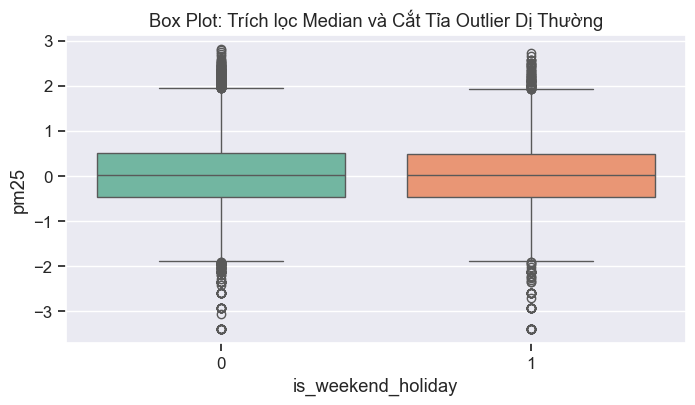

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='is_weekend_holiday', y='pm25', palette='Set2', ax=ax)
ax.set_title('Box Plot: Trích lọc Median và Cắt Tỉa Outlier Dị Thường')
plt.show()

---
## 🌡️ 5. Heatmap (Bản Đồ Hồng Ngoại Tương Quan)

**🎯 Mục đích:** Check toàn cục đại cảnh (Kiểu Ma trận).

**✨ Điều Kiện Lý Tưởng:** 10 -> 20 biến Continuous. Dữ liệu chạy Linear (Tuyến tính).

**⚠️ NHƯỢC ĐIỂM (Weakness):** Lỗ hổng lớn nhất: Nó chỉ bắt được Tương Quan Tuyến Tính (Hàm bậc 1). Nếu dữ liệu biến hóa cong Parabol (ví dụ Lượng mưa nhỏ cây mọc tốt gập đầu vào, Mưa bão to cây úng chết lộn ngược), Heatmap sẽ đánh giá mối quan hệ là Số 0 (Mù).

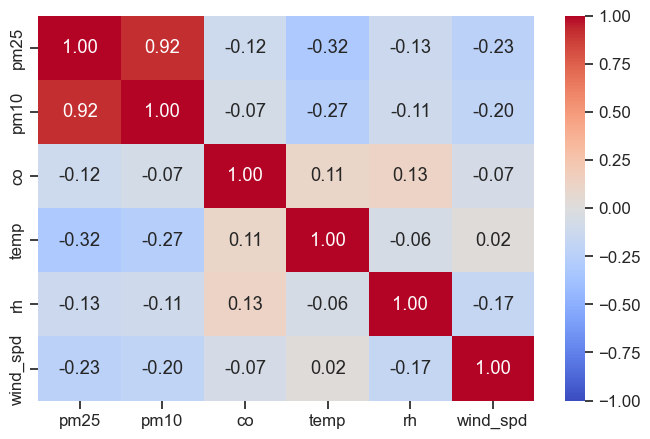

In [7]:
cols = ['pm25', 'pm10', 'co', 'temp', 'rh', 'wind_spd']
corr_matrix = df[cols].corr()
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
plt.show()

---
## 📊 6. Bar Plot (Biểu Đồ Cột So Sánh Aggregator)

**🎯 Mục đích:** Dùng Trực cảm Chiều Cao để so kèo chênh lệch giữa các Danh Mục (như Tuần, Tháng).

**✨ Điều Kiện Lý Tưởng:**  Số Danh mục $< 20$. Trục Y là Chỉ số gom nhóm (Trung Bình Mean/ Tổng Sum).

**⚠️ NHƯỢC ĐIỂM (Weakness):** Ẩn Giấu hoàn toàn Outliers và Độ Lệch thô. Đồng thời, Cực Kì Ăn Gian nếu người vẽ Cố tình Không kéo Trục Y lùi về chân số 0 (Zero-base Y axis), Mắt người xem sẽ bị nhầm lẫn con kiến khổng lồ bằng con voi.

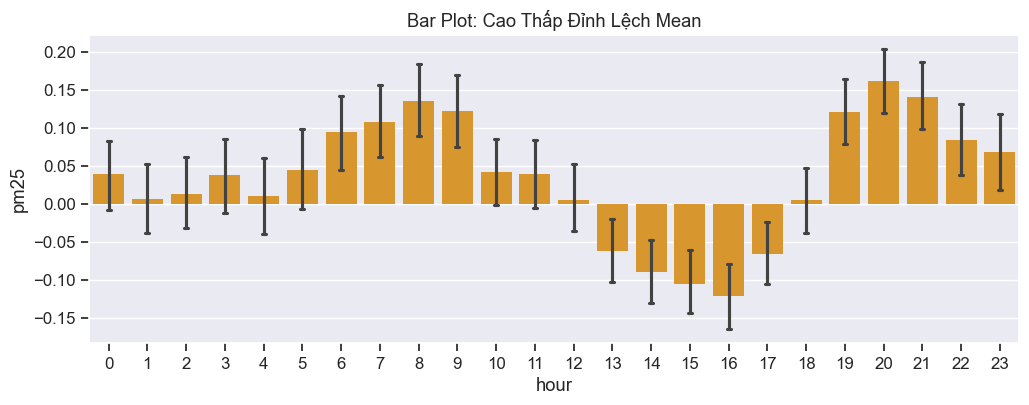

In [8]:
df['hour'] = df.index.hour
fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=df, x='hour', y='pm25', color='#f39c12', ax=ax, capsize=0.1)
ax.set_title('Bar Plot: Cao Thấp Đỉnh Lệch Mean')
plt.show()

---
## 🎻 7. Violin Plot (Lai Chéo Box Plot + Histogram)

**🎯 Mục đích:** Sửa khuyết điểm Che Giấu Bụng mỡ của cái Hộp vuông BoxPlot.

**✨ Điều Kiện Lý Tưởng:** Nhóm dữ liệu vừa cần soi Box, vừa chứa sự biến động Đa Đỉnh thù hình đồi núi.

**⚠️ NHƯỢC ĐIỂM (Weakness):** Những người lãnh đạo/sếp không hiểu biết về Data Science cực kỳ ghét biểu đồ này vì họ không hiểu... cái hình phình phình kia là cái quái gì. Nó dội áp lực thị giác cực mạnh.

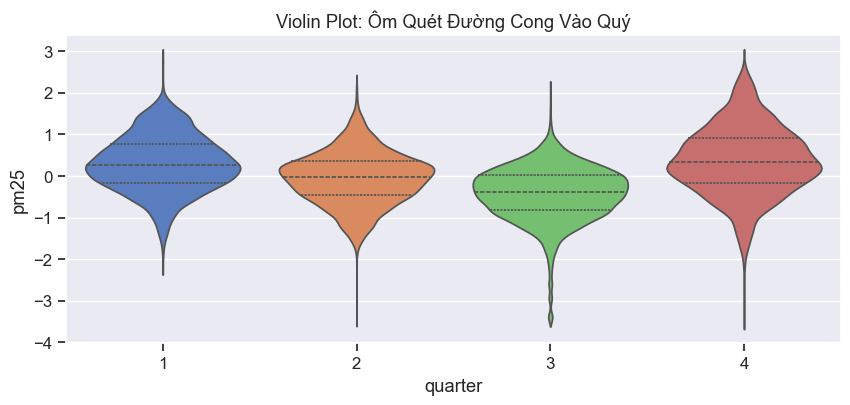

In [9]:
df['quarter'] = df.index.quarter
fig, ax = plt.subplots(figsize=(10, 4))
sns.violinplot(data=df, x='quarter', y='pm25', palette='muted', inner="quartile", ax=ax)
ax.set_title('Violin Plot: Ôm Quét Đường Cong Vào Quý')
plt.show()

---
## 🧭 8. Hexbin Plot (Vá Lỗi Over-Plotting Của Scatter)

**🎯 Mục đích:** Tính toán Mật Độ 2 Chiều. 

**✨ Điều Kiện Lý Tưởng:** Dành cứu mạng khi Dữ liệu lên ngưỡng Khủng Hoảng (Hàng triệu/chục ngàn con số).

**⚠️ NHƯỢC ĐIỂM (Weakness):** Làm Lố. Do gộp gom vào Ô Tổ Ong (Binning), bạn đánh rơi rớt bớt cái nhìn thực sự của những Điểm Nằm Ngoài Lề dị nhân (Những con bò rạc rài ở mép sẽ bị nhạt phai trên bản đồ rỗ).

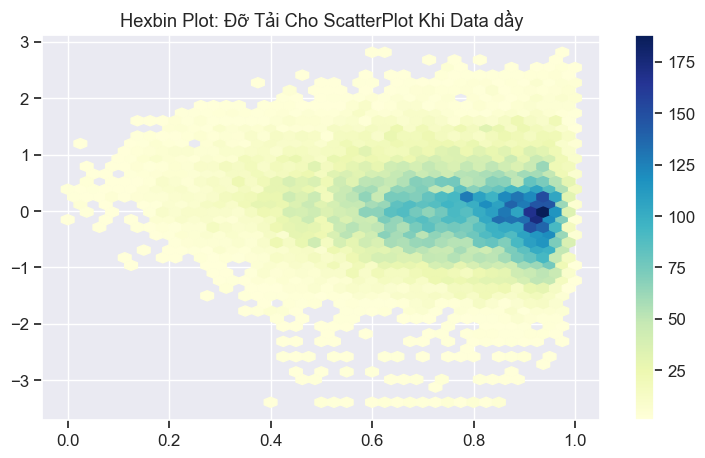

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
hb = ax.hexbin(x=df['rh'], y=df['pm25'], gridsize=40, cmap='YlGnBu', mincnt=1)
cb = fig.colorbar(hb, ax=ax)
ax.set_title('Hexbin Plot: Đỡ Tải Cho ScatterPlot Khi Data dầy')
plt.show()

---
## 🎆 9. Pair Plot (Siêu Cỗ Quét Cắt Lớp)

**🎯 Mục đích:** Lên đồ toàn mảng Scatter mọi góc mọi cặp.

**✨ Điều Kiện Lý Tưởng:** Exploratory Data Analytics (EDA) thần tốc ở đầu dự án.

**⚠️ NHƯỢC ĐIỂM (Weakness):** SÁT THỦ PHẦN CỨNG. Treo tung máy tính nếu nhét $> 20$ Cột kèm $> 5000$ điểm. Gần như Vô Hại/Vô Dụng ở Report báo cáo vì cái ô bé như Lỗ Kim.

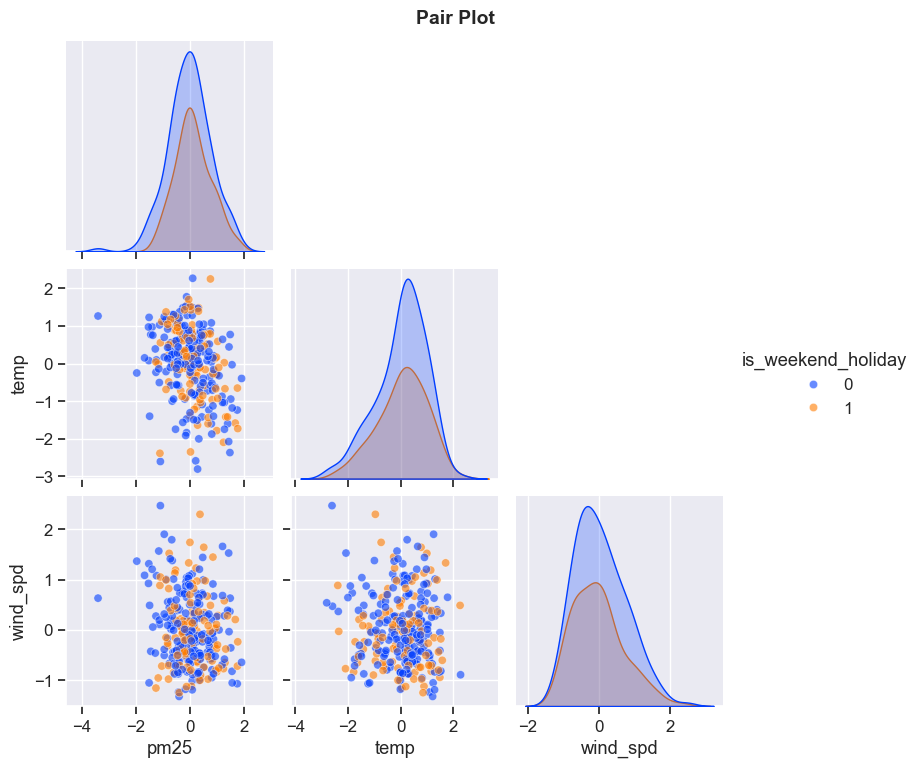

In [11]:
cols_pair = ['pm25', 'temp', 'wind_spd', 'is_weekend_holiday']
df_tiny = df[cols_pair].sample(300, random_state=42) 
sns.pairplot(df_tiny, hue='is_weekend_holiday', corner=True, palette='bright', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot', y=1.02, fontweight='bold', fontsize=14)
plt.show()

## 🍩 10. Pie / Donut Chart (Bánh Trộn Tròn Xoay)

**🎯 Mục đích:** Thể hiện % thành phần chiếm Tỷ Trọng so với Cái Toàn Bộ Cục (Total 100%).

**✨ Điều Kiện Lý Tưởng:** Biến rời rạc, ít hơn $4-5$ danh mục.

**⚠️ NHƯỢC ĐIỂM (Weakness):** Giới Phân Tích CỰC KỲ KHINH MIỆT CHÚNG! Lý do: Não người ước tính góc cắt (Góc cung Tròn) cực độ tồi tệ. Trừ phi góc cắt chen lệch dã man như $80\%$ vs $20\%$, còn nếu góc cắt là $32\%$ với $34\%$ đập vào mắt con người coi như bằng nhau. Phải sử dụng Biểu đồ Vành Khăn (Donut) để làm rỗng tâm thì trông đỡ rối mắt hơn Pie Chart gốc.

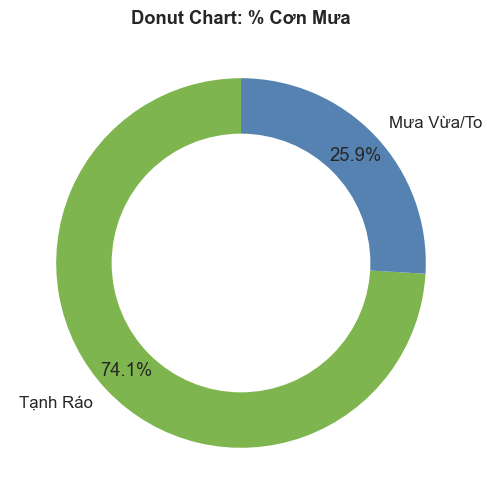

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
# Tính tổng giờ Mưa vs Không Mưa làm cái bánh donut
rain_stats = [ (df['precip'] == 0).sum(), (df['precip'] > 0).sum() ]
ax.pie(rain_stats, labels=['Tạnh Ráo', 'Mưa Vừa/To'], autopct='%1.1f%%', 
       colors=['#7eb54e', '#5582b0'], startangle=90, pctdistance=0.85)

# Đục lỗ cái bánh tạo Rỗng Tâm (Donut Chart)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)
ax.set_title('Donut Chart: % Cơn Mưa', fontweight='bold')
plt.show()

---
## 🌊 11. Area Plot (Diện Tích Cọc Tích Lũy)

**🎯 Mục đích:** Giống hệt Line Plot nhưng tô mực mảng đắp bù màu xuống đáy. Khắc họa "Khối lượng" (Volume) dồn toa thay vì chỉ là đường cắt ngang.

**✨ Điều Kiện Lý Tưởng:** Dữ liệu mang tính Lũy kế Tổng tài sản (Share Market) chia ra 3 phe Nhóm.

**⚠️ NHƯỢC ĐIỂM (Weakness):** Khi dồn chồng mép lên nhau (Stacked), dải băng dưới cùng (đáy Y) bị đo 1 mốc chuẩn, dải trượt dòng thứ 2 lại đè gù lên trên lưng lớp thứ 1 làm biến dạng mặt cắt, và lớp thứ 3 mọc trên lớp 2 gây lừa đảo độ dày kinh khủng.

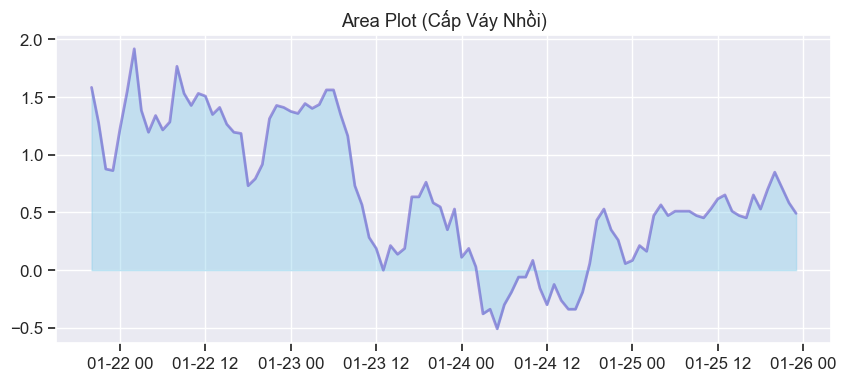

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
df_week = df.iloc[500:600] # Lấy mẩu bé xíu 100 giờ

# Nhồi màu xốp
ax.fill_between(df_week.index, df_week['pm25'], color="skyblue", alpha=0.4)
ax.plot(df_week.index, df_week['pm25'], color="Slateblue", alpha=0.6, linewidth=2)
ax.set_title('Area Plot (Cấp Váy Nhồi)')
plt.show()

---
## 🐝 12. Strip / Swarm Plot (Đám Yến Nhẩy Múa)

**🎯 Mục đích:** Lật Tẩy hết lòng mề 100%! Không dùng Hộp vuông để giấu như Boxplot ngụy trang, Swarm plot rải cặn kẽ TỪNG ĐIỂM BAY 1 đè rải sát vào đường Line, đánh giá chân thật về từng giọt đứt đoạn của dân cư.

**✨ Điều Kiện Lý Tưởng:** Dataset Mini (Dưới vài trăm bản ghi) cho 1 khối Categorical.

**⚠️ NHƯỢC ĐIỂM (Weakness):** Bạn sẽ BỊ LỖI CHẶN/ CẢNH BÁO nếu cố nhét hàng ngàn dữ liệu. Thuật toán cố gắng tính khoảng cách để các hạt đậu không đè gập lên vỡ vụn nhau nên nó tốn hàng tỉ phép tính đan chéo (Chạy chậm vô địch).

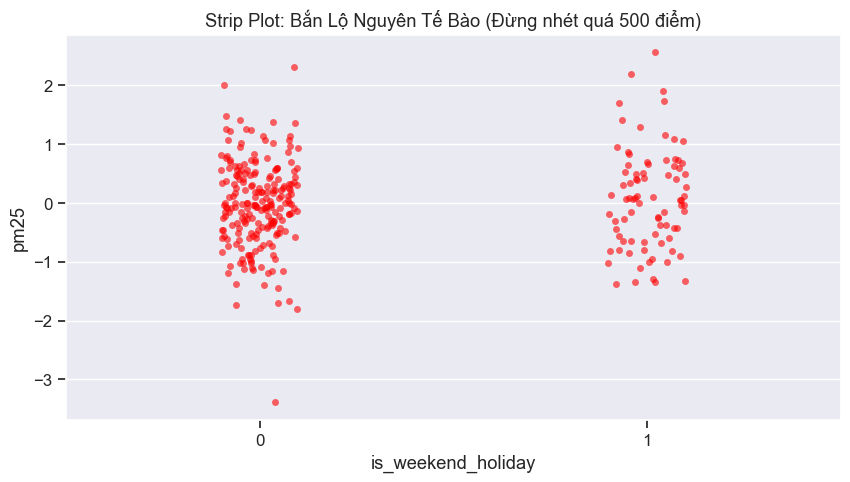

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
df_tiny2 = df.sample(300, random_state=1) # Dữ liệu lớn nổ máy ngay

# Jitter Plot bóp rải chấm
sns.stripplot(data=df_tiny2, x='is_weekend_holiday', y='pm25', jitter=True, 
              alpha=0.6, color="red", ax=ax)
ax.set_title('Strip Plot: Bắn Lộ Nguyên Tế Bào (Đừng nhét quá 500 điểm)')
plt.show()

---
## 🤝 13. Joint Plot (Biểu Đồ Sát Nhập Tuyệt Đỉnh Không Gian)

**🎯 Mục đích:** Phiên bản Tối Thượng kết hợp của 1 cặp đôi. Đánh gục 2 biến một lúc. Giữa là Scatter Plot. Phía trên chóp Rìa là Histogram của Trục X. Quanh mép Phải Rìa là Histogram Trục Y.

**✨ Điều Kiện Lý Tưởng:** Muốn mổ xẻ duy nhất 1 và chỉ 1 cặp tình nhân (Ví dụ PM2.5 và PM10) không để dư góc chết.

**⚠️ NHƯỢC ĐIỂM (Weakness):** Khá cồng kềnh, Cốt lỗi không gian choàng nặng mạn lề nên tốn diện tích vẽ báo cáo. Chỉ ngắm được cặp duy nhất mọt lúc.

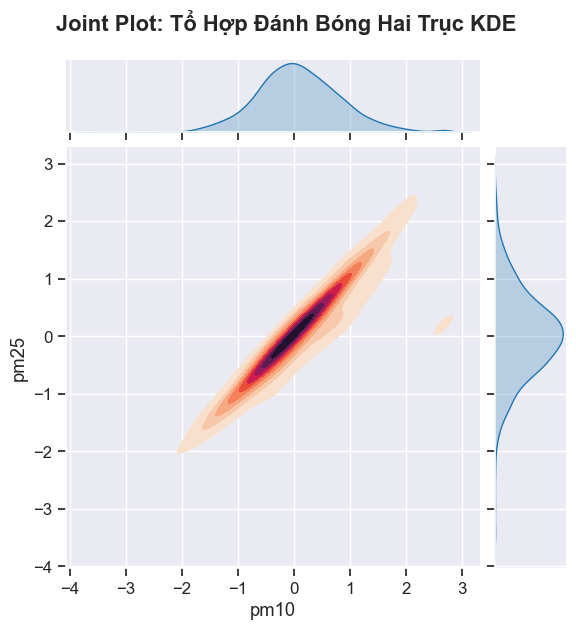

In [15]:
# Jointplot tự tạo figure nên ko dùng subplots
# Biểu đồ sương mù tương ứng Mật độ KDE 2 Chiều bên trong.
g = sns.jointplot(data=df_sample, x='pm10', y='pm25', kind="kde", 
                  cmap="rocket_r", fill=True, height=6)

g.fig.suptitle('Joint Plot: Tổ Hợp Đánh Bóng Hai Trục KDE',
               y=1.05, fontweight='bold')
plt.show()